In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

claims = pd.read_csv('claims.csv', sep=',')
policies = pd.read_csv('policies.csv', sep=',')

print(claims.head())
print(claims.describe())
print(claims.info())
print(claims.isnull().sum())

print(policies.head())
print(policies.describe())
print(policies.info())
print(policies.isnull().sum())

   POLICY_ID  CLAIM_NB  CLAIM_TOTAL_AMOUNT
0        139         1              303.00
1        190         1             1981.84
2        414         1             1456.55
3        424         2            10834.00
4        463         1             3986.67
          POLICY_ID      CLAIM_NB  CLAIM_TOTAL_AMOUNT
count  2.494400e+04  24944.000000        2.494400e+04
mean   2.262558e+06      1.060135        2.401749e+03
std    1.578475e+06      0.289868        3.026475e+04
min    1.390000e+02      1.000000        1.000000e+00
25%    1.082690e+06      1.000000        7.497875e+02
50%    2.130098e+06      1.000000        1.172000e+03
75%    3.178542e+06      1.000000        1.346400e+03
max    6.113971e+06     16.000000        4.075401e+06
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24944 entries, 0 to 24943
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   POLICY_ID           24944 non-null  int64  
 

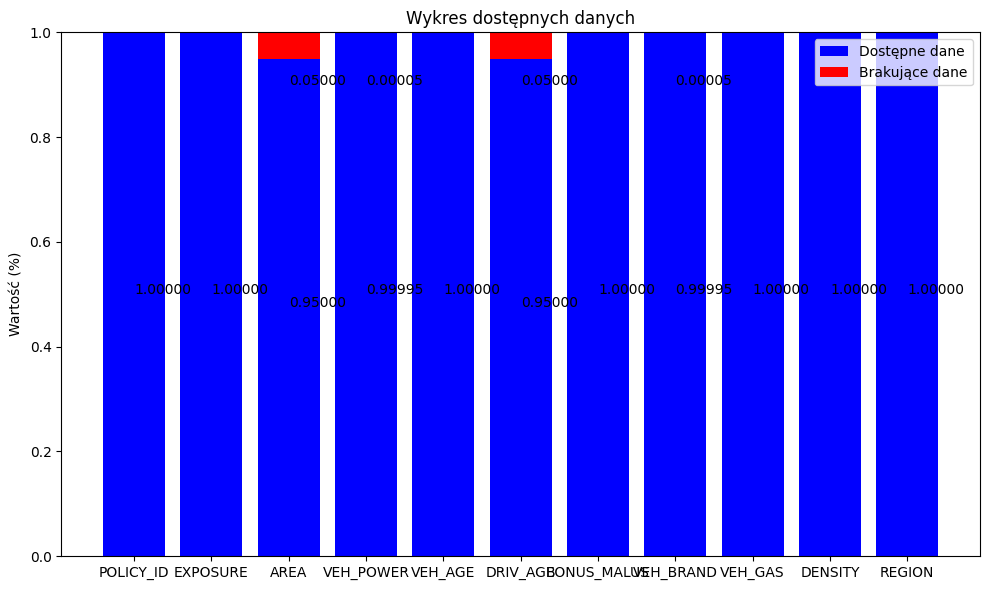

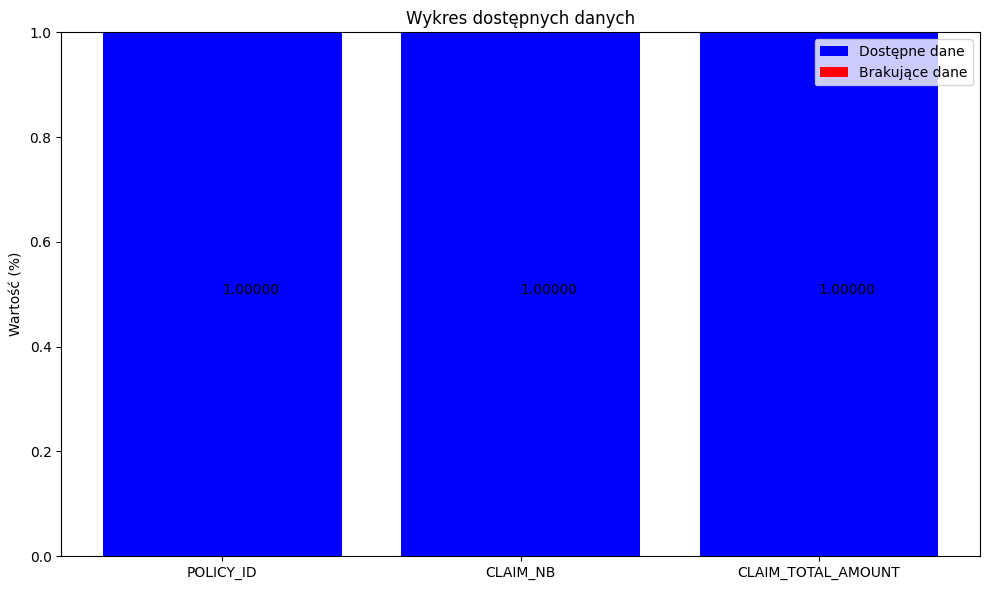

In [ ]:
def missing_plot(data):
    # numeric_data = data.select_dtypes(include=np.number)
    missing = data.isnull().mean()
    non_missing = 1 - missing

    x = data.columns

    missing_y = missing.values
    non_missing_y = non_missing.values

    plt.figure(figsize=(10, 6))

    plt.bar(x, non_missing_y, label='Dostępne dane', color='b')
    plt.bar(x, missing_y, bottom=non_missing_y, label='Brakujące dane', color='r')

    for i in range(len(x)):
        plt.text(x[i], non_missing_y[i] / 2, f"{non_missing_y[i]:.5f}")

        if missing_y[i] > 0:
            plt.text(x[i], non_missing_y[i] + missing_y[i] - 0.1, f"{missing_y[i]:.5f}")

    plt.title("Wykres dostępnych danych")
    plt.ylabel("Wartość (%)")
    plt.legend()
    plt.tight_layout()
    plt.show()

missing_plot(policies)
missing_plot(claims)

In [ ]:
def correlation_plot(data):
    data.select_dtypes(include=np.number)
    numeric_data = data.select_dtypes(include=np.number)
    corr_matrix = numeric_data.corr()
    plt.figure(figsize=(8, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu')
    plt.title("Macierz korelacji")
    plt.tight_layout()
    plt.show()


# correlation_plot(policies)
# correlation_plot(claims)

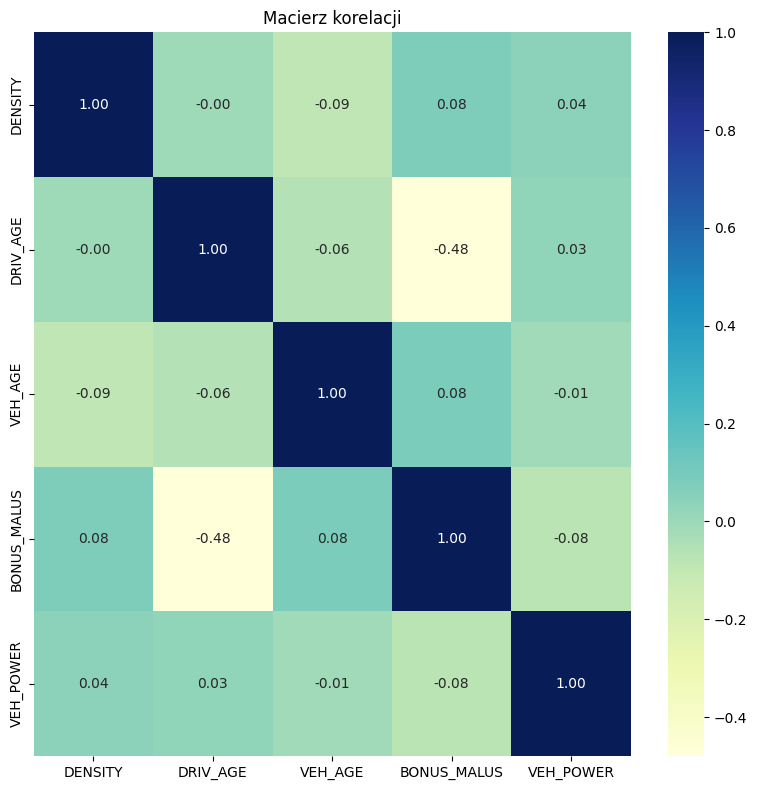

In [ ]:
numeric_cols = ['DENSITY', 'DRIV_AGE', 'VEH_AGE', 'BONUS_MALUS', 'VEH_POWER']
numeric_cols = [c for c in numeric_cols if c in policies.columns]

corr_matrix = policies[numeric_cols].corr()

plt.figure(figsize=(8,8))
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Macierz korelacji")
plt.tight_layout()
plt.show()

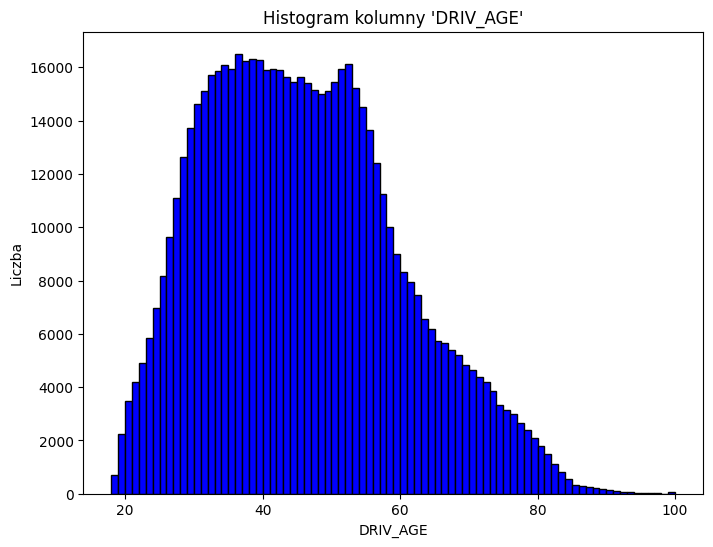

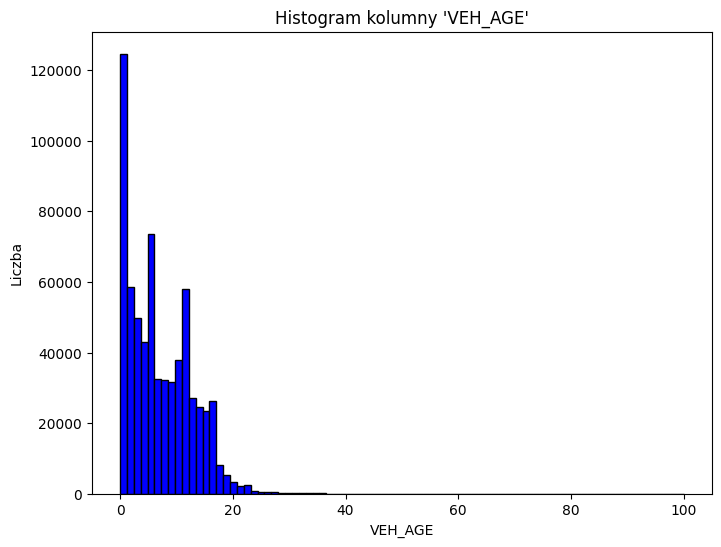

In [ ]:
def histogram_plot(data, data_name):
    plt.figure(figsize=(8, 6))
    plt.hist(data[data_name].dropna(), bins=82, color='blue', edgecolor='black')
    plt.title(f"Histogram kolumny '{data_name}'")
    # plt.xlim(20, 100)
    plt.xlabel(data_name)
    plt.ylabel("Liczba")
    plt.show()

histogram_plot(policies, "DRIV_AGE")
histogram_plot(policies, "VEH_AGE")

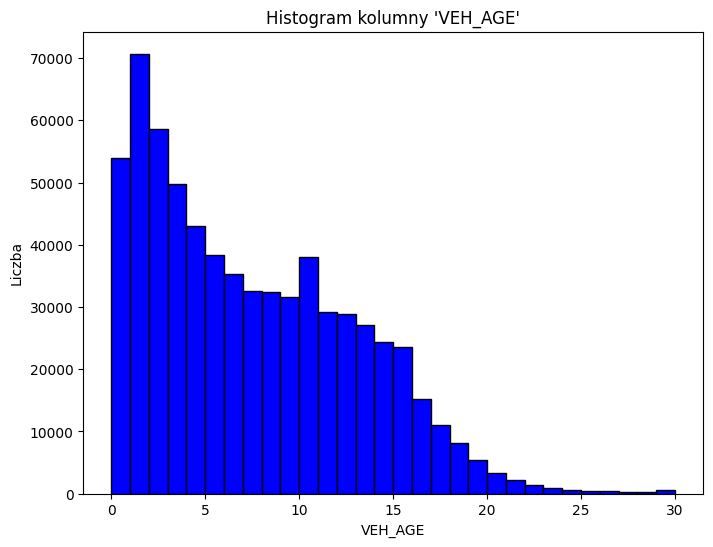

In [ ]:
def histogram_plot_veh(data, data_name):
    plt.figure(figsize=(8, 6))

    filtered = data[data_name].dropna()
    filtered = filtered[(filtered >= 0) & (filtered <= 30)]

    plt.hist(filtered, bins=30, color='blue', edgecolor='black')
    plt.title(f"Histogram kolumny '{data_name}'")
    plt.xlabel(data_name)
    plt.ylabel("Liczba")
    plt.show()

histogram_plot_veh(policies, "VEH_AGE")

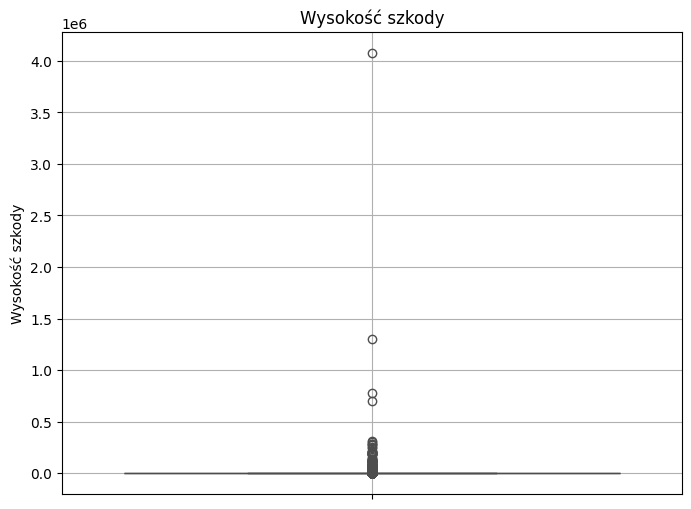

In [ ]:
def ratio_plot(data, data_name_1, data_name_2):
    ratio = data[data_name_1] / data[data_name_2]

    plt.figure(figsize=(8, 6))

    sns.boxplot(y=ratio, color='blue')
    # sns.stripplot(y=ratio, color='blue')#, alpha=0.1)

    plt.title(f"Wysokość szkody")
    # plt.xlabel(data_name_1)
    plt.ylabel("Wysokość szkody")
    # plt.ylim(0, 10_000)
    plt.grid(True)
    plt.show()

ratio_plot(claims, "CLAIM_TOTAL_AMOUNT", "CLAIM_NB")

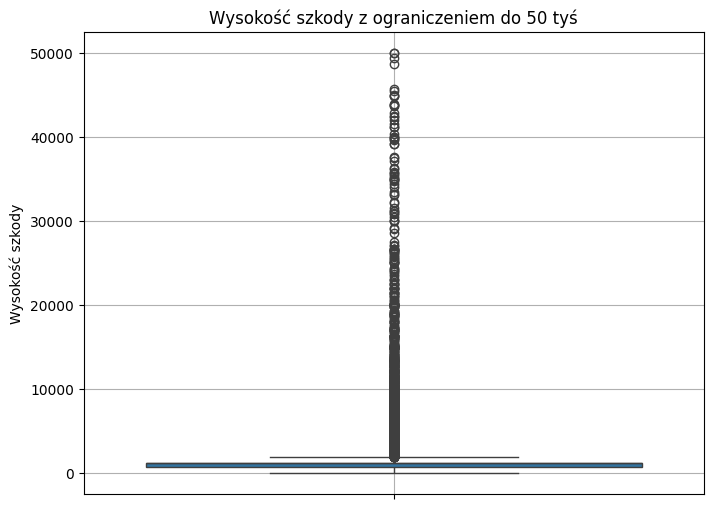

In [ ]:
def ratio_plot2(data, data_name_1, data_name_2):
    ratio = data[data_name_1] / data[data_name_2]
    ratio = ratio[ratio <= 50_000]

    plt.figure(figsize=(8, 6))

    sns.boxplot(y=ratio)

    plt.title(f"Wysokość szkody z ograniczeniem do 50 tyś")
    # plt.xlabel(data_name_1)
    plt.ylabel("Wysokość szkody")
    plt.grid(True)
    plt.show()

ratio_plot2(claims, "CLAIM_TOTAL_AMOUNT", "CLAIM_NB")